# DengAI · 2. Exploratory data analysis

Each section asks one question, answers it with a Seaborn chart, and ends
with the **decision** it implies for preprocessing, validation, or modelling.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "dengai").is_dir())
sys.path.insert(0, str(ROOT))
OUTPUT_DIR = ROOT / "notebooks" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dengai.config import CITY_NAMES, DATE_COLUMN, TARGET_COLUMN, WEATHER_FEATURES
from dengai.data import city_frame, find_data_dir, interpolate_climate, load_data
from dengai.plotting import CITY_COLORS, MUTED, SERIES, set_style

set_style()
train, test, template = load_data(find_data_dir(ROOT))
train["City"] = train["city"].map(CITY_NAMES)
test["City"] = test["city"].map(CITY_NAMES)

## 1. How do cases evolve over time?

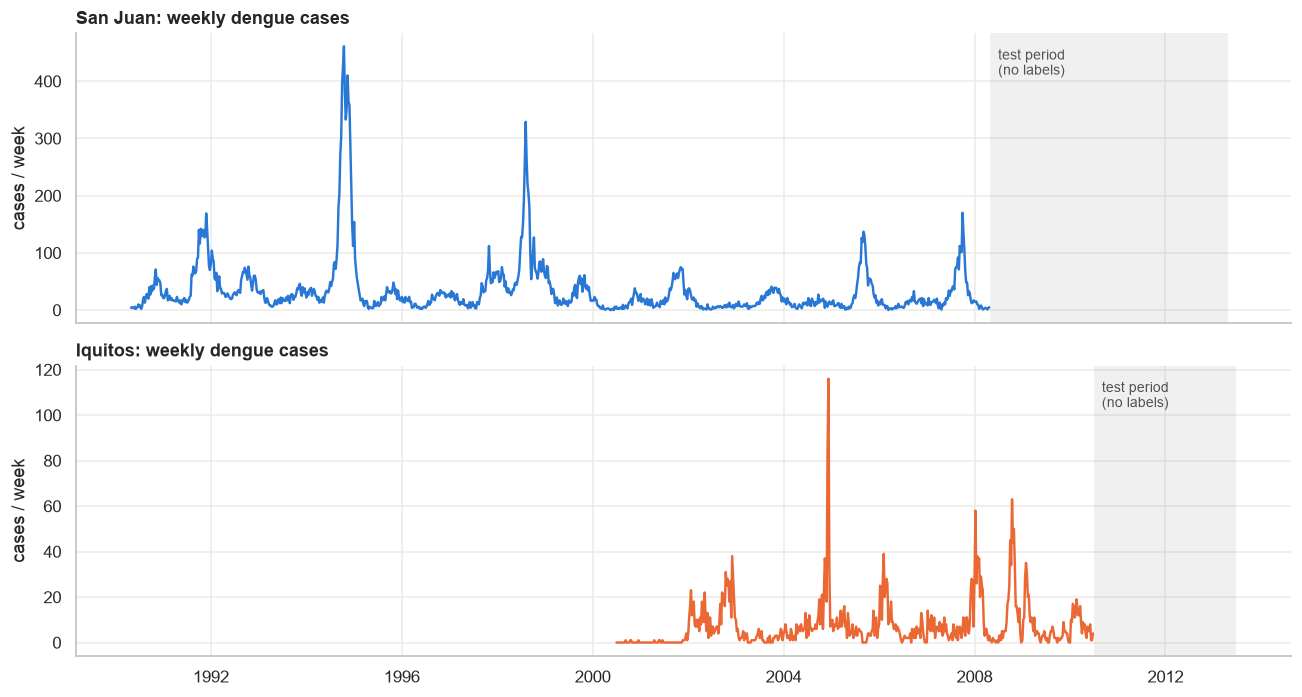

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
for ax, (city, name) in zip(axes, CITY_NAMES.items()):
    data = train[train["city"].eq(city)]
    sns.lineplot(data=data, x=DATE_COLUMN, y=TARGET_COLUMN, ax=ax, color=CITY_COLORS[city])
    test_dates = test.loc[test["city"].eq(city), DATE_COLUMN]
    ax.axvspan(test_dates.min(), test_dates.max(), color=MUTED, alpha=0.12, lw=0)
    ax.text(test_dates.min(), ax.get_ylim()[1] * 0.85, "  test period\n  (no labels)", color="#52514e", fontsize=9)
    ax.set(title=f"{name}: weekly dengue cases", xlabel="", ylabel="cases / week")
plt.tight_layout()

**Finding.** San Juan has rare, very large outbreaks (1994, 1998) with
long quiet periods in between. Iquitos has far fewer cases and many weeks
near zero. The test periods are long blocks after the training data.

**Decision.** Validation must imitate this: train on the past and predict a
future block (notebook 04). A model that smooths everything toward the
average will miss the peaks that dominate the absolute error.

## 2. What does the target distribution look like?

,mean,median,variance,p90,maximum,zero_weeks,skew,variance / mean
City,,,,,,,,
Iquitos,7.57,5.0,115.90,19.1,116,0.18,4.00,15.32
San Juan,34.18,19.0,2640.05,71.0,461,0.00,4.48,77.24


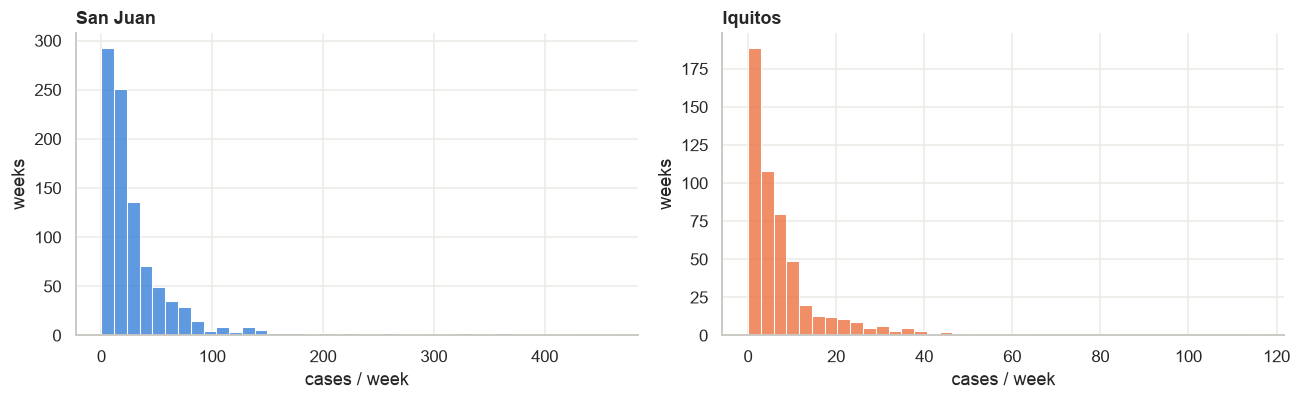

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, (city, name) in zip(axes, CITY_NAMES.items()):
    sns.histplot(train.loc[train["city"].eq(city), TARGET_COLUMN], bins=40, ax=ax, color=CITY_COLORS[city])
    ax.set(title=name, xlabel="cases / week", ylabel="weeks")
plt.tight_layout()

stats = train.groupby("City")[TARGET_COLUMN].agg(
    mean="mean", median="median", variance="var", p90=lambda s: s.quantile(0.9), maximum="max",
    zero_weeks=lambda s: (s == 0).mean(), skew="skew",
)
stats["variance / mean"] = stats["variance"] / stats["mean"]
stats.round(2)

**Finding.** Both targets are strongly right-skewed counts. The variance is
tens of times larger than the mean (**overdispersion**), so a Poisson
assumption would be too narrow. The median is well below the mean, and
almost one Iquitos week in five has zero cases.

**Decision.**
* Use **MAE** as the quality measure. It is the competition metric, it is
  in interpretable units (cases per week), and it is not dominated by the
  single largest outbreak the way RMSE would be.
* Handle the skew in the model: the MLP trains directly on an MAE loss
  (which targets the conditional median); the Iquitos forest models
  `log1p(cases)`; the San Juan Extra Trees uses a Poisson split criterion.
* Fit **separate models per city**: their scales differ by a factor of about 5.

## 3. How strong is seasonality?

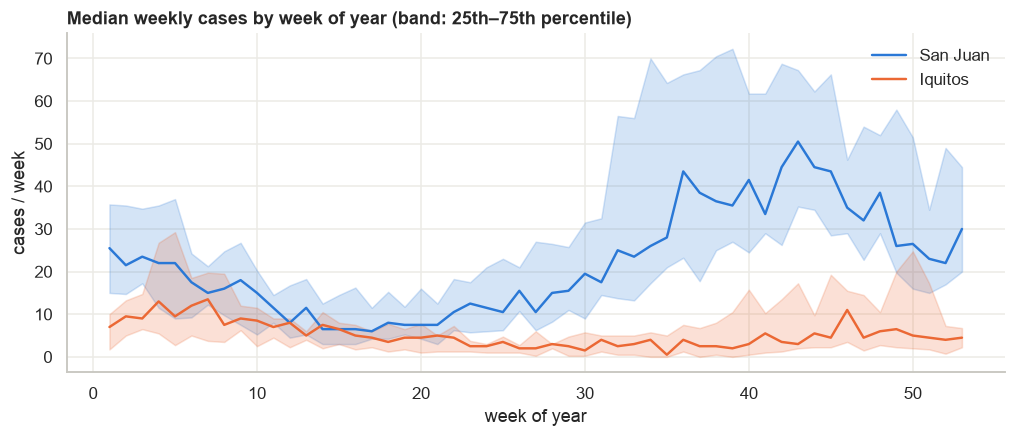

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(
    data=train, x="weekofyear", y=TARGET_COLUMN, hue="City", palette=CITY_COLORS,
    estimator="median", errorbar=("pi", 50), ax=ax,
)
ax.set(title="Median weekly cases by week of year (band: 25th–75th percentile)", xlabel="week of year", ylabel="cases / week")
ax.legend(title="");

**Finding.** Both cities peak in the second half of the year (San Juan
around weeks 35–45; Iquitos is flatter and highest from about week 45
through week 10, i.e. December to March). The interquartile band is wide: **the week of the year
alone does not determine the number of cases.**

**Decision.**
* Encode the season cyclically (sin/cos), so week 52 and week 1 are neighbours.
* Use a *seasonal median* as a baseline that any useful model must beat.
* Add the recent climate history to explain why some seasons are much
  worse than others.

## 4. Do outbreak years differ?

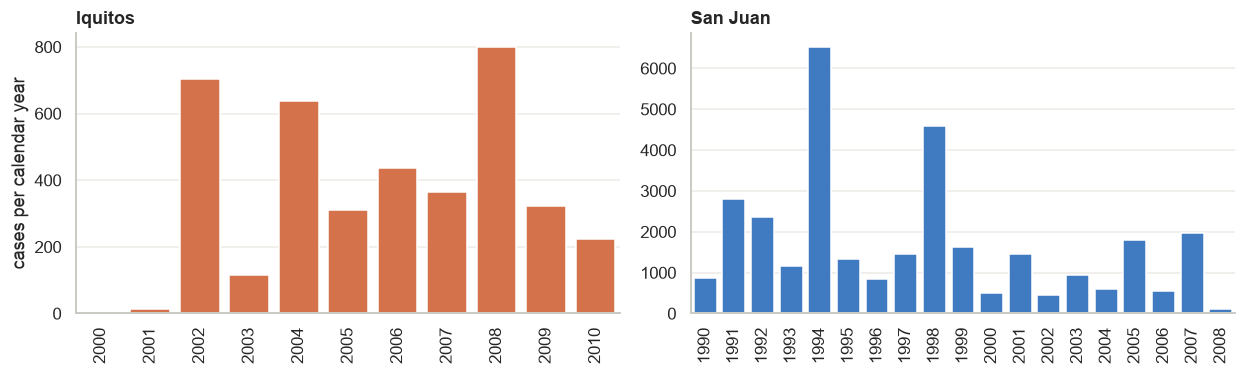

In [5]:
yearly = (
    train.assign(season=train[DATE_COLUMN].dt.year)
    .groupby(["City", "season"])[TARGET_COLUMN].sum().reset_index()
)
g = sns.catplot(
    data=yearly, x="season", y=TARGET_COLUMN, col="City", hue="City", palette=CITY_COLORS,
    kind="bar", sharex=False, sharey=False, height=3.6, aspect=1.6, legend=False,
)
g.set_axis_labels("", "cases per calendar year")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=90)
g.set_titles("{col_name}");

**Finding.** Annual totals vary several-fold from year to year. In San Juan
a few outbreak years account for a large share of all cases.

**Decision.** Report an **outbreak MAE** (error on weeks above the 90th
percentile of the training target) alongside the overall MAE. This
catches models that look good on average only because they predict
quiet weeks well.

## 5. Which values are missing?

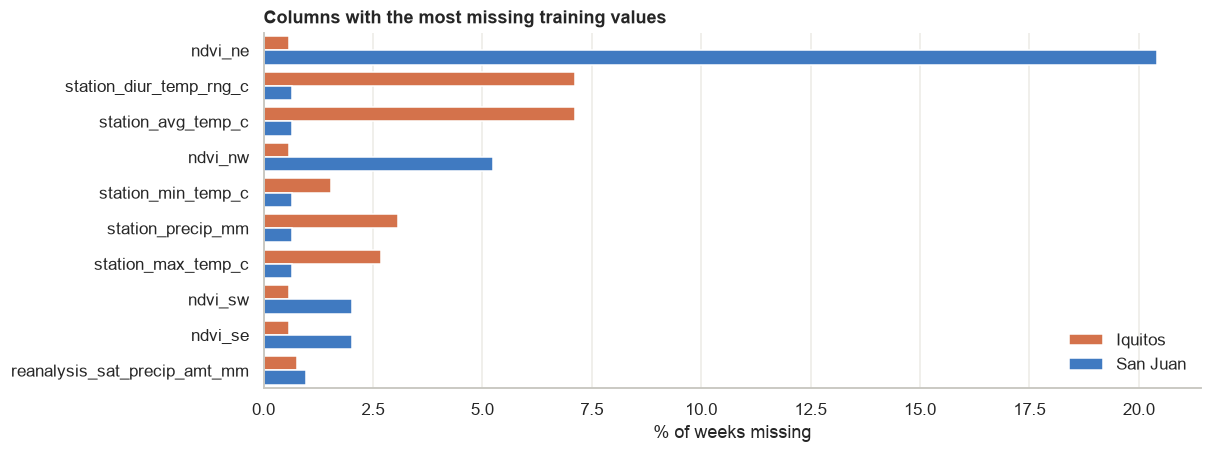

In [6]:
feature_columns = [c for c in train.columns if c not in ("city", "City", "year", "weekofyear", DATE_COLUMN, TARGET_COLUMN)]
missing = (
    pd.concat([train.assign(split="train"), test.assign(split="test")])
    .groupby(["City", "split"])[feature_columns].apply(lambda g: g.isna().mean() * 100)
    .stack().rename("percent missing").reset_index().rename(columns={"level_2": "column"})
)
top = missing.groupby("column")["percent missing"].max().sort_values(ascending=False).index[:10]
fig, ax = plt.subplots(figsize=(11, 4.2))
sns.barplot(
    data=missing[missing["column"].isin(top) & missing["split"].eq("train")],
    y="column", x="percent missing", hue="City", palette=CITY_COLORS, order=top, ax=ax,
)
ax.set(title="Columns with the most missing training values", ylabel="", xlabel="% of weeks missing")
ax.legend(title="");

In [7]:
def longest_gap(series: pd.Series) -> int:
    run = best = 0
    for missing_value in series.isna():
        run = run + 1 if missing_value else 0
        best = max(best, run)
    return best

gaps = pd.DataFrame({
    name: {column: longest_gap(city_frame(train, city)[column]) for column in WEATHER_FEATURES}
    for city, name in CITY_NAMES.items()
})
print("Longest run of consecutive missing weeks (climate features):")
gaps.max()

Longest run of consecutive missing weeks (climate features):


San Juan    3
Iquitos     6
dtype: int64

**Finding.** Missing values are rare (a few percent), except for San Juan's
north-east NDVI (about 20%). Gaps in the climate series are short runs of
consecutive weeks, and no city starts or ends with a missing row.

**Decision.** Weather changes smoothly from week to week, so **linear
interpolation along time** within each city is a sensible fill for the
climate histories. For the tree models, missing values are imputed with the
training-fold median inside the model pipeline, which cannot leak
validation data. No rows are dropped.

## 6. Are the climate variables redundant?

precipitation_amt_mm == reanalysis_sat_precip_amt_mm in every row: True


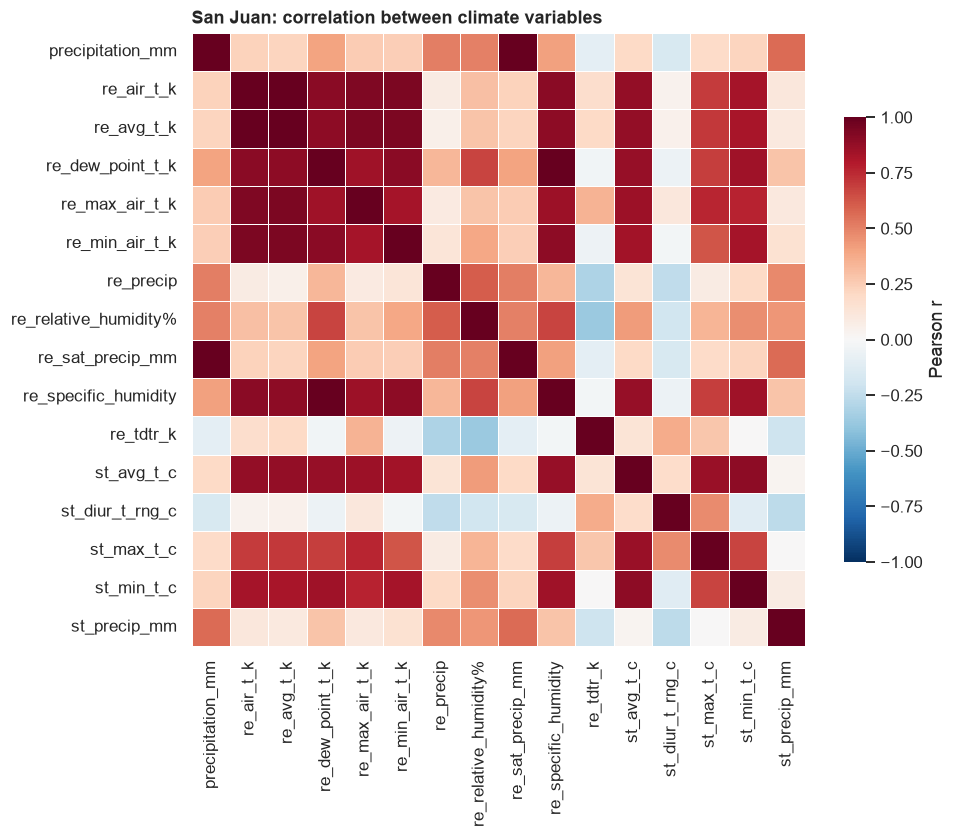

In [8]:
sj = city_frame(train, "sj")
short = {c: c.replace("reanalysis_", "re_").replace("station_", "st_").replace("_temp", "_t")
         .replace("_percent", "%").replace("_amt", "").replace("_kg_per_m2", "").replace("_g_per_kg", "")
         for c in WEATHER_FEATURES}
corr = sj[WEATHER_FEATURES].rename(columns=short).corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.7, "label": "Pearson r"})
ax.set_title("San Juan: correlation between climate variables")
print("precipitation_amt_mm == reanalysis_sat_precip_amt_mm in every row:",
      bool((train["precipitation_amt_mm"] - train["reanalysis_sat_precip_amt_mm"]).abs().max() == 0))

**Finding.** The variables form tight blocks: the temperature measures are
highly correlated, as are the humidity and dew-point measures, and the
rainfall sources agree partially. `precipitation_amt_mm` and
`reanalysis_sat_precip_amt_mm` are **identical columns**.

**Decision.** Many inputs carry overlapping information. Prefer models
that tolerate correlated inputs (tree ensembles; a regularised MLP with
dropout) over coefficient-based interpretations. Adding many lagged
copies of every variable would multiply the number of inputs without
adding much new signal; notebook 03 builds a compact alternative.

## 7. Does climate act with a delay?

,City,variable,lag (weeks),Spearman ρ
162,Iquitos,dew point,0,0.368
219,Iquitos,min air temp,3,0.321
246,Iquitos,rainfall (satellite),3,0.166
135,Iquitos,specific humidity,0,0.372
193,Iquitos,station avg temp,4,0.224
36,San Juan,dew point,9,0.522
90,San Juan,min air temp,9,0.481
116,San Juan,rainfall (satellite),8,0.297
9,San Juan,specific humidity,9,0.523
66,San Juan,station avg temp,12,0.567


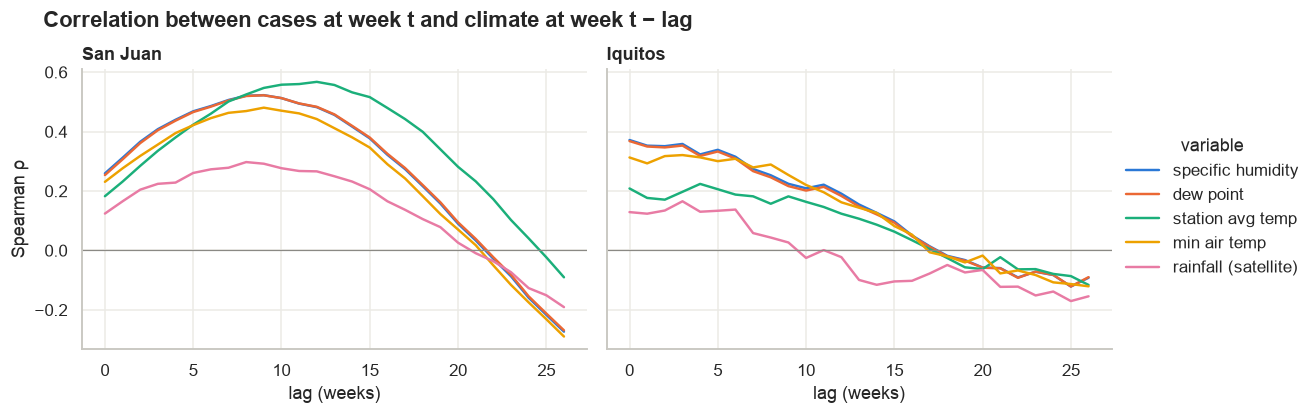

In [9]:
variables = {
    "reanalysis_specific_humidity_g_per_kg": "specific humidity",
    "reanalysis_dew_point_temp_k": "dew point",
    "station_avg_temp_c": "station avg temp",
    "reanalysis_min_air_temp_k": "min air temp",
    "precipitation_amt_mm": "rainfall (satellite)",
}
rows = []
for city, name in CITY_NAMES.items():
    frame = interpolate_climate(city_frame(train, city))
    for column, label in variables.items():
        for lag in range(0, 27):
            rows.append({"City": name, "variable": label, "lag (weeks)": lag,
                         "Spearman ρ": frame[TARGET_COLUMN].corr(frame[column].shift(lag), method="spearman")})
lags = pd.DataFrame(rows)
g = sns.relplot(data=lags, x="lag (weeks)", y="Spearman ρ", hue="variable", col="City",
                kind="line", height=3.6, aspect=1.45, palette=SERIES[:5])
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.axhline(0, color=MUTED, lw=0.8)
g.figure.suptitle("Correlation between cases at week t and climate at week t − lag", y=1.04, x=0.05, ha="left", weight="bold")
lags.loc[lags.groupby(["City", "variable"])["Spearman ρ"].idxmax()].round(3)

**Finding.** Humidity, dew point and temperature correlate most strongly
with cases **several weeks earlier** in San Juan (peaks at 8–12 weeks),
consistent with mosquito development and viral incubation times. In
Iquitos the correlation is highest for the last 0–4 weeks and fades
after about 15 weeks. The useful delay differs by variable and city.

**Decision.** The features must include **past climate**. A single fixed
lag is not enough, because different variables and cities have different
delays.

## 8. Single past weeks versus accumulated conditions

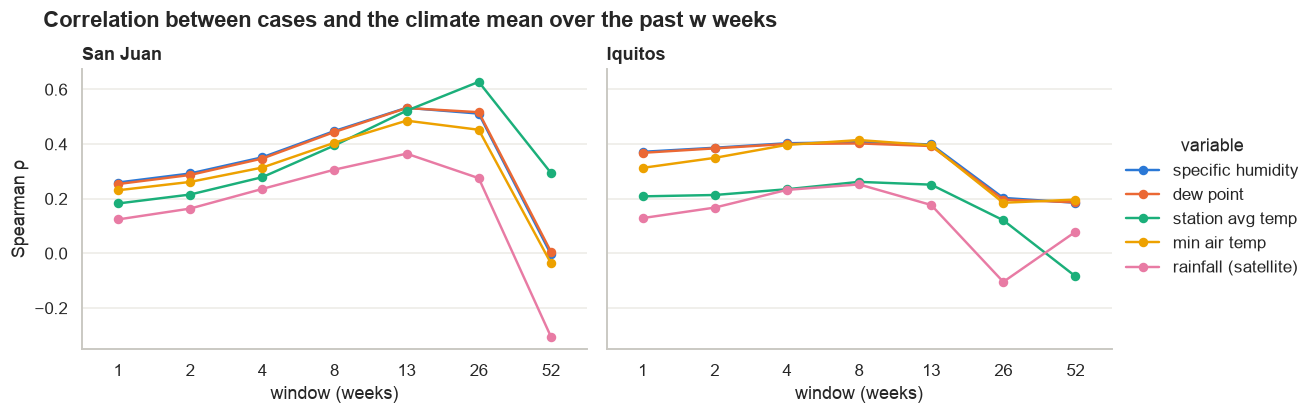

In [10]:
rows = []
for city, name in CITY_NAMES.items():
    frame = interpolate_climate(city_frame(train, city))
    for column, label in variables.items():
        for window in (1, 2, 4, 8, 13, 26, 52):
            rows.append({"City": name, "variable": label, "window (weeks)": window,
                         "Spearman ρ": frame[TARGET_COLUMN].corr(frame[column].rolling(window).mean(), method="spearman")})
windows = pd.DataFrame(rows)
g = sns.catplot(data=windows, x="window (weeks)", y="Spearman ρ", hue="variable", col="City",
                kind="point", height=3.6, aspect=1.45, palette=SERIES[:5], markersize=5, linewidth=1.6)
g.set_titles("{col_name}")
g.figure.suptitle("Correlation between cases and the climate mean over the past w weeks", y=1.04, x=0.05, ha="left", weight="bold");

**Finding.** For several variables the *average over the past few months*
correlates with cases more strongly than any single week: 13–26-week
means in San Juan, 4–13-week means in Iquitos. The informative timescale
differs between variables (temperature keeps its signal over 26 weeks
in San Juan, rainfall does not) and between cities.

**Decision.** Describe the climate history at several timescales at once
(2 to 52 weeks), rather than guessing one lag. This is the idea behind
the final **multiscale summary** features (notebook 03).

## 9. Are past cases informative, and can we use them?

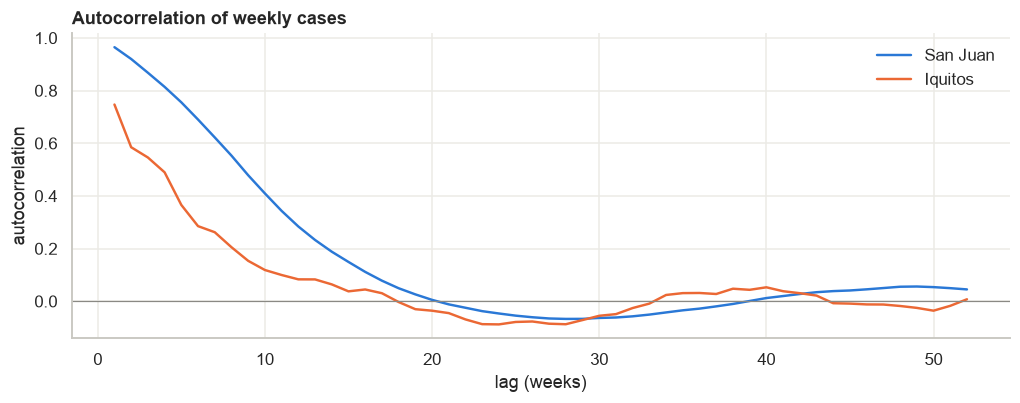

In [11]:
rows = []
for city, name in CITY_NAMES.items():
    cases = city_frame(train, city)[TARGET_COLUMN]
    rows += [{"City": name, "lag (weeks)": lag, "autocorrelation": cases.autocorr(lag)} for lag in range(1, 53)]
fig, ax = plt.subplots(figsize=(11, 3.6))
sns.lineplot(data=pd.DataFrame(rows), x="lag (weeks)", y="autocorrelation", hue="City", palette=CITY_COLORS, ax=ax)
ax.axhline(0, color=MUTED, lw=0.8)
ax.set(title="Autocorrelation of weekly cases")
ax.legend(title="");

**Finding.** Cases are strongly autocorrelated over many weeks, so last
week's count would be an excellent predictor of this week's.

**Decision.** We **cannot use it**: during the 3–5-year test horizon the
true past counts are unknown. Feeding back our own predictions would let
errors compound. All models use climate and calendar inputs only. The
autocorrelation is also why **shuffled K-fold is invalid** here:
neighbouring weeks are near-copies, so random splits would leak.

## 10. Are the two cities' climates comparable?

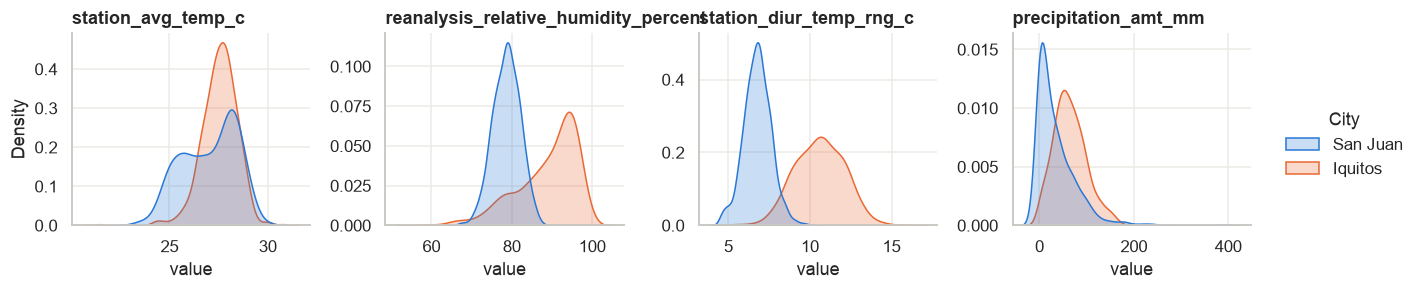

In [12]:
compare = ["station_avg_temp_c", "reanalysis_relative_humidity_percent", "station_diur_temp_rng_c", "precipitation_amt_mm"]
long = train.melt(id_vars="City", value_vars=compare, var_name="variable", value_name="value")
g = sns.displot(data=long, x="value", hue="City", col="variable", col_wrap=4, kind="kde",
                palette=CITY_COLORS, fill=True, common_norm=False, facet_kws={"sharex": False, "sharey": False},
                height=2.8, aspect=1.05)
g.set_titles("{col_name}");

**Finding.** Iquitos (Amazon rainforest) is more humid, has a larger
daily temperature range and more rainfall than coastal San Juan.
The cities occupy different climate regimes.

**Decision.** The climate–dengue relationship cannot be assumed to be the
same in both places. This confirms **one model per city**, each with its
own hyper-parameters.

## 11. Does the test-period climate look like the training climate?

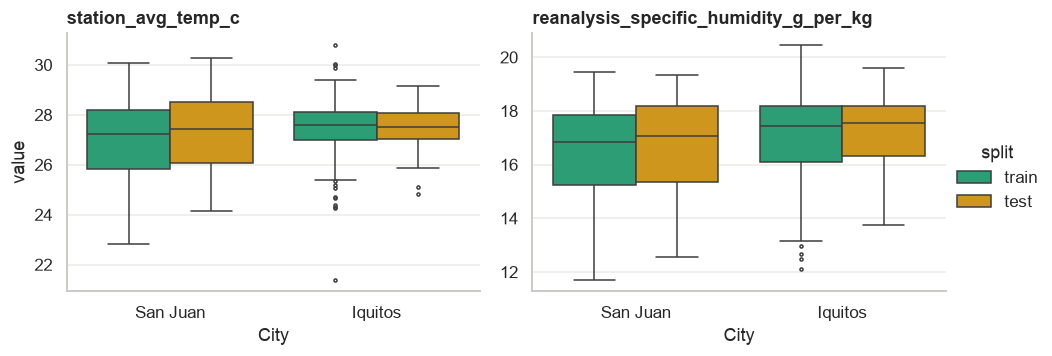

In [13]:
both = pd.concat([train.assign(split="train"), test.assign(split="test")])
long = both.melt(id_vars=["City", "split"], value_vars=["station_avg_temp_c", "reanalysis_specific_humidity_g_per_kg"],
                 var_name="variable", value_name="value")
g = sns.catplot(data=long, x="City", y="value", hue="split", col="variable", kind="box",
                sharey=False, height=3.4, aspect=1.3, palette=[SERIES[2], SERIES[3]], fliersize=2)
g.set_titles("{col_name}");

**Finding.** The test climate lies within the training range for both
cities, so the models are not asked to extrapolate to unseen conditions.

## Summary of findings and decisions

| Finding | Decision |
|---|---|
| Rare large outbreaks; skewed, overdispersed counts | MAE as the metric, plus an outbreak MAE; skew-aware losses (MAE loss, log1p, Poisson) |
| Cities differ in scale and climate | Separate model per city |
| Strong but noisy seasonality | Cyclic week encoding; seasonal-median baseline |
| Climate acts with variable delays; accumulated conditions matter | Past-only climate history at several timescales |
| Strongly correlated / duplicate climate variables | Compact summaries instead of hundreds of raw lags; regularised models |
| Strong case autocorrelation, but labels unknown at test time | No case lags; chronological (not shuffled) validation |
| Short gaps in climate data | Linear interpolation (MLP) / fold-median imputation (trees) |